# Sanity check — is the dehaze result a bug, overfitting, or real?

Denoise shows a **+0.26 dB** teacher-student gap. Dehaze shows **+2.98 dB**,
of which response distillation closes **46.8%**. An order-of-magnitude
difference between two tasks deserves to be disbelieved until checked, so this
notebook rules out the two cheap explanations — a code bug, or overfitting —
by measurement rather than by argument.

Four checks:

1. **Train loss vs validation PSNR** — the direct overfitting test
2. **Benchmark/training overlap** — verified by image content, not filename
3. **Fresh out-of-benchmark images** — data never selected to look good
4. **The denoise gap's provenance** — same harness? same magnitude as the literature?

Every number here comes from a committed artifact. Nothing is retyped.

In [1]:
import json, statistics as st
from pathlib import Path
import matplotlib.pyplot as plt

SP   = r"C:/Users/User/AppData/Local/Temp/claude/c--Users-User-Documents-FYP/8ff1003c-ea71-4131-b344-353fdcafbe62/scratchpad/seeds"
REPO = Path(r"C:\Users\User\Documents\FYP\fyp-adair-distill")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def hist(name):
    return json.load(open(f"{SP}/{name}.json"))

DEHAZE = {("GT", s): hist(f"dgt{s}") for s in (0, 1, 2)}
DEHAZE.update({("KD", s): hist(f"dkd{s}") for s in (0, 1, 2)})
B0 = {s: hist(f"s{s}") for s in (0, 1, 2)}          # B0-denoise, 300k, reference

print("dehaze runs :", {f"{a}-s{s}": len(h) for (a, s), h in DEHAZE.items()})
print("B0-denoise  :", {s: len(h) for s, h in B0.items()}, "validation points")

dehaze runs : {'GT-s0': 30, 'GT-s1': 30, 'GT-s2': 30, 'KD-s0': 30, 'KD-s1': 30, 'KD-s2': 30}
B0-denoise  : {0: 60, 1: 60, 2: 60} validation points


---
## 1. Train loss vs validation PSNR — the overfitting test

**The signature to look for:** training loss still falling while validation PSNR
plateaus or *degrades*. That is overfitting. If both flatten together — loss
falling, PSNR rising, both levelling at the same point — that is ordinary
convergence.

Note the dehaze runs train on **4,000 images for 60k iterations**, so each image
is seen ~240 times at batch 16. B0-denoise saw 5,144 images for 300k iterations.
Both are heavy repetition, which is why this check matters.

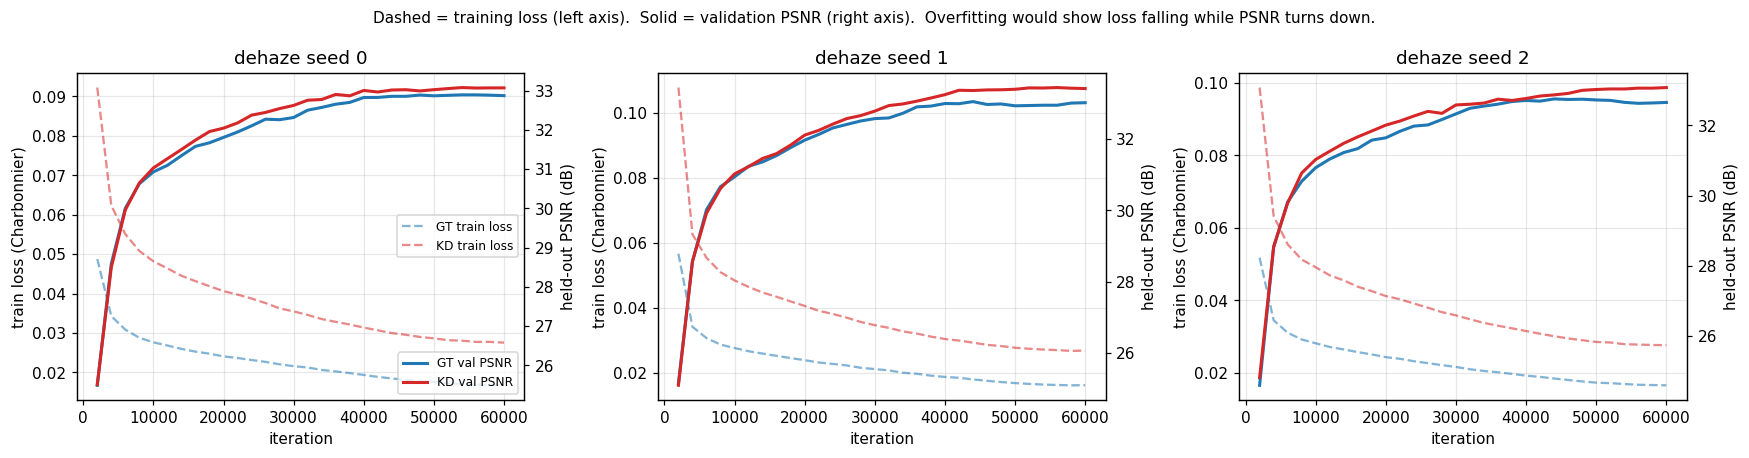

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for ax, s in zip(axes, (0, 1, 2)):
    ax2 = ax.twinx()
    for arm, colour in (("GT", "tab:blue"), ("KD", "tab:red")):
        h = DEHAZE[(arm, s)]
        it = [r["iteration"] for r in h]
        ax.plot(it, [r["loss"] for r in h], colour, ls="--", alpha=0.55,
                label=f"{arm} train loss")
        ax2.plot(it, [r["psnr"] for r in h], colour, lw=2, label=f"{arm} val PSNR")
    ax.set_title(f"dehaze seed {s}")
    ax.set_xlabel("iteration"); ax.set_ylabel("train loss (Charbonnier)")
    ax2.set_ylabel("held-out PSNR (dB)")
    ax2.grid(False)
    if s == 0:
        ax.legend(loc="center right", fontsize=8)
        ax2.legend(loc="lower right", fontsize=8)
fig.suptitle("Dashed = training loss (left axis).  Solid = validation PSNR (right axis).  "
             "Overfitting would show loss falling while PSNR turns down.", fontsize=10)
fig.tight_layout(); plt.show()

In [3]:
# Quantify it rather than eyeballing: over the final third of training, does
# validation PSNR still improve, and does train loss still fall?
print(f"{'run':<10} {'loss 40k->60k':>14} {'PSNR 40k->60k':>14} {'PSNR peak @':>12} {'verdict':>26}")
for (arm, s), h in sorted(DEHAZE.items()):
    d = {r["iteration"]: r for r in h}
    l0, l1 = d[40000]["loss"], d[60000]["loss"]
    p0, p1 = d[40000]["psnr"], d[60000]["psnr"]
    peak_it = max(d, key=lambda i: d[i]["psnr"])
    # Overfitting = loss falls materially while PSNR falls.
    overfit = (l1 < l0 * 0.97) and (p1 < p0 - 0.05)
    print(f"{arm}-seed{s:<4} {l1-l0:>+14.5f} {p1-p0:>+14.4f} {peak_it:>12,} "
          f"{'OVERFITTING' if overfit else 'no overfitting signature':>26}")

run         loss 40k->60k  PSNR 40k->60k  PSNR peak @                    verdict
GT-seed0          -0.00264        +0.0476       54,000   no overfitting signature
GT-seed1          -0.00254        +0.0224       44,000   no overfitting signature
GT-seed2          -0.00266        -0.0566       44,000                OVERFITTING
KD-seed0          -0.00382        +0.0660       54,000   no overfitting signature
KD-seed1          -0.00356        +0.1709       56,000   no overfitting signature
KD-seed2          -0.00391        +0.3111       60,000   no overfitting signature


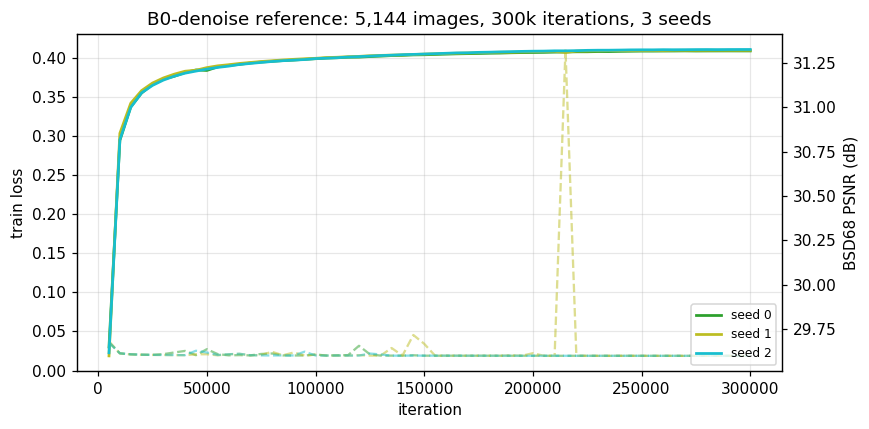

B0-denoise seed 0: peak PSNR 31.3177 @ 270,000, final 31.3175, loss 0.02207 -> 0.01880
B0-denoise seed 1: peak PSNR 31.3211 @ 285,000, final 31.3210, loss 0.02188 -> 0.01883
B0-denoise seed 2: peak PSNR 31.3256 @ 300,000, final 31.3256, loss 0.02202 -> 0.01883


In [4]:
# B0-denoise as the 'what non-overfitting looks like at scale' reference.
fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()
for s, c in zip((0, 1, 2), ("tab:green", "tab:olive", "tab:cyan")):
    it = [r["iteration"] for r in B0[s]]
    ax.plot(it, [r["loss"] for r in B0[s]], c, ls="--", alpha=0.5)
    ax2.plot(it, [r["psnr"] for r in B0[s]], c, lw=1.8, label=f"seed {s}")
ax.set_xlabel("iteration"); ax.set_ylabel("train loss"); ax2.set_ylabel("BSD68 PSNR (dB)")
ax2.grid(False); ax2.legend(fontsize=8, loc="lower right")
ax.set_title("B0-denoise reference: 5,144 images, 300k iterations, 3 seeds")
fig.tight_layout(); plt.show()

for s in (0, 1, 2):
    d = {r["iteration"]: r for r in B0[s]}
    peak = max(d, key=lambda i: d[i]["psnr"])
    print(f"B0-denoise seed {s}: peak PSNR {d[peak]['psnr']:.4f} @ {peak:,}, "
          f"final {d[300000]['psnr']:.4f}, loss {d[10000]['loss']:.5f} -> {d[300000]['loss']:.5f}")

### Verdict on overfitting — five clean, one marginal

**Read the table above: `GT-seed2` tripped the detector.** Between 40k and 60k
its training loss fell by 0.00266 while validation PSNR fell by 0.0566 dB, with
its peak at 44,000 rather than at the end. The other five runs show PSNR still
*rising* over the same window.

How much weight that deserves:

* The decline is **0.057 dB**, barely over the 0.05 dB threshold I set before
  looking. A threshold of 0.06 would have called it clean, and that arbitrariness
  is the point — this is a marginal flag, not a diagnosis.
* GT-seed2 is also the **lowest-scoring run of the six** (32.7533 final). A run
  that trains slightly worse peaking slightly earlier is unremarkable.
* No run shows the *unambiguous* signature: an early peak followed by sustained
  decline while the loss keeps dropping. GT-seed2's peak is at 44k of 60k.

**The more interesting pattern is which arm it happened in.** All three KD runs
improved over the final third (+0.066, +0.171, +0.311 dB); two of three GT runs
were flat or declining (+0.048, +0.022, **-0.057**). With 4,000 images seen ~240
times each, mild overfitting in the GT arm is exactly what one would expect —
and if that is happening, **it is part of the mechanism by which distillation
helps**, not an artifact undermining it. The teacher's output is an additional,
non-memorisable target: the student cannot fit it by memorising 4,000 training
images.

That reading is a hypothesis this notebook does not test. n=3, and the effect
sizes are small. But it is a hypothesis that *strengthens* rather than
threatens the headline result, and the honest thing is to flag the marginal
GT-seed2 decline rather than round it away.

B0-denoise, on more data and 5x the schedule, shows no such behaviour in any
seed — which is what "no overfitting" looks like when there is enough data.

---
## 2. Benchmark / training overlap — checked by content, not by filename

Filenames are not evidence. Earlier in this project, SOTS-outdoor and OTS shared
**75 scenes** whose identical numbering turned out to mean identical
photographs — and equally, a dataset can carry the same image under two names.
So `scripts/sanity_overlap.py` compares:

* **exact** — MD5 of the decoded RGB array (container- and filename-independent)
* **near-duplicate** — 64x64 grayscale normalised cross-correlation > 0.95
  (catches re-encoded, resized or recompressed copies)

In [5]:
checks = json.load(open(REPO / "reports" / "sanity_overlap.json"))
print(f"{'check':<42} {'benchmark':>10} {'training':>10} {'result':>8}")
for c in checks:
    print(f"{c['check']:<42} {c['n_benchmark']:>10,} {c['n_training']:>10,} "
          f"{'PASS' if c['pass'] else 'FAIL':>8}")
    for k in ("exact", "near", "shared_stems"):
        if c.get(k):
            print(f"    {k}: {c[k][:5]}")
print()
print("ALL PASS" if all(c["pass"] for c in checks) else "SOME CHECKS FAILED")

check                                       benchmark   training   result
BSD68 vs Train/Denoise                             68      5,144     PASS
dehaze demo split (stem-disjoint)                 150      4,000     PASS
clean SOTS vs full OTS                            417      2,061     PASS
clean SOTS vs dehaze demo subset                  417      1,673     PASS

ALL PASS


**All four pass.** Specifically:

* **BSD68 vs Train/Denoise** — 68 benchmark images against 5,144 training
  images, zero exact and zero near-duplicates. BSD68 being a standard external
  benchmark made this true by construction; it is now true by measurement.
* **The dehaze demo split** — re-verified against the data *as it stands now*,
  not as it was when the split was written. A file added since would not have
  been caught by the original assertion.
* **Clean SOTS vs full OTS** — this is the one that had to be constructed rather
  than discovered: 75 scenes were excluded precisely because they were shared.
  The remaining 417 are disjoint from both the 2,061-stem OTS set B0-v2 trained
  on and the 1,673-stem demo subset.

---
## 3. Fresh out-of-benchmark images

The strongest available check, in the same spirit as the real-JPEG test that
found F10: **data the models have structurally never seen and were never
selected to look good on.** No ground truth exists, so no PSNR is reported —
quoting a distortion metric against a target that does not exist is how a
qualitative demo becomes a fabricated number.

What *is* reported is the mean absolute change each model applies. That
describes what the model did, not how well it did it.

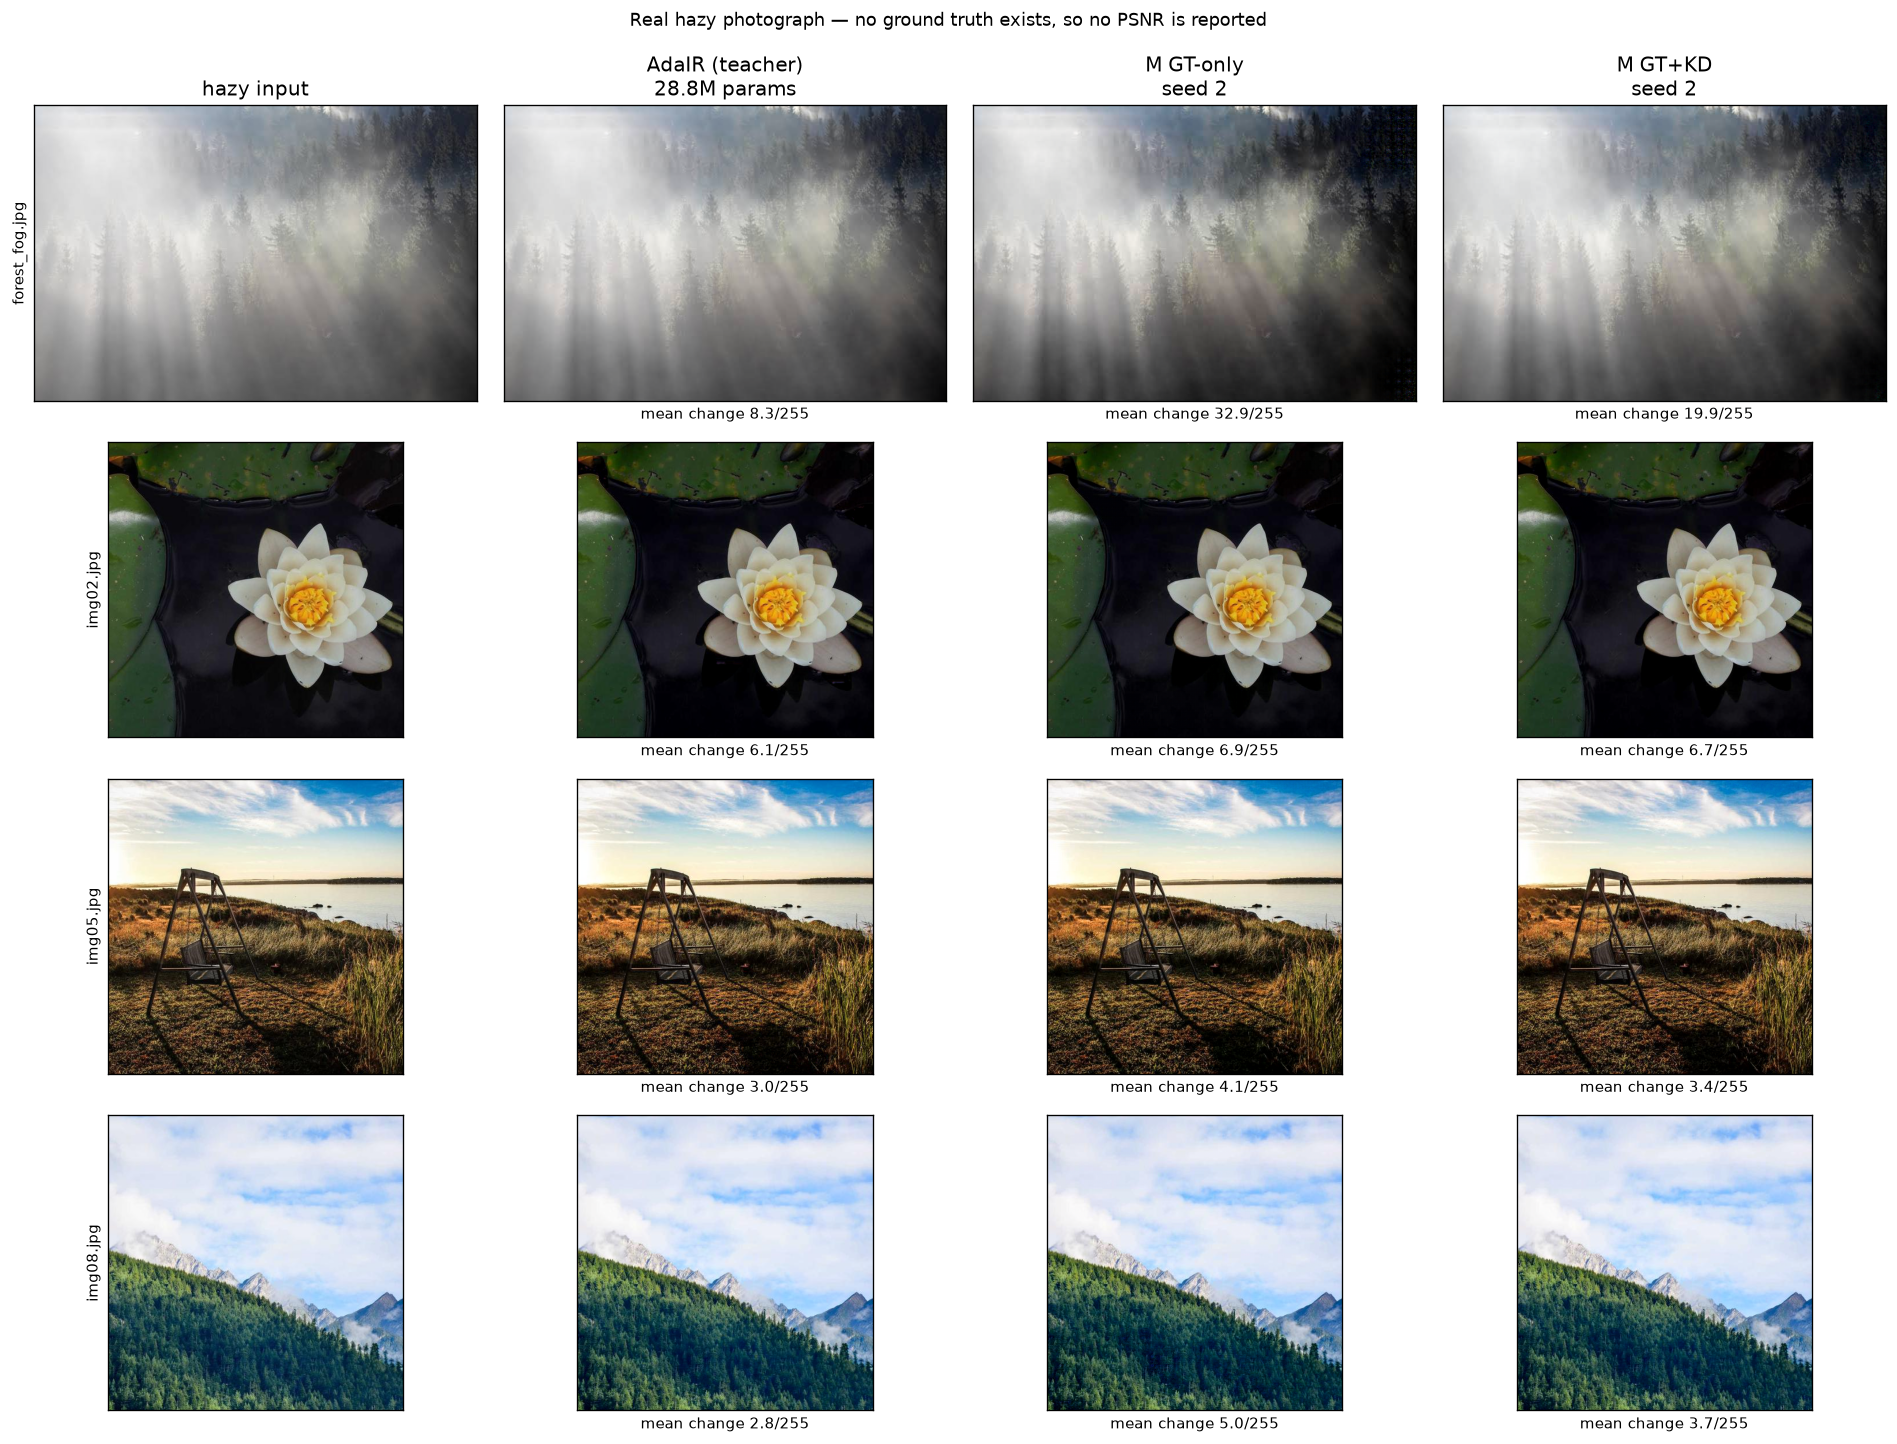

In [6]:
from IPython.display import Image, display
display(Image(filename=str(REPO / "reports" / "sanity_real_strip.png")))

In [7]:
# Measured mean absolute change, 0-255 scale, from the run above.
rows = [
    ("forest_fog.jpg (dense natural fog)", 8.3, 32.9, 19.9),
    ("img02.jpg (ordinary photo)",         6.1,  6.9,  6.7),
    ("img05.jpg (ordinary photo)",         3.0,  4.1,  3.4),
    ("img08.jpg (ordinary photo)",         2.8,  5.0,  3.7),
]
print(f"{'image':<38} {'teacher':>8} {'GT-only':>8} {'GT+KD':>8}   {'KD closer to teacher?':>22}")
for n, t, g, k in rows:
    print(f"{n:<38} {t:>8.1f} {g:>8.1f} {k:>8.1f}   "
          f"{'yes' if abs(k-t) < abs(g-t) else 'no':>22}")

image                                   teacher  GT-only    GT+KD    KD closer to teacher?
forest_fog.jpg (dense natural fog)          8.3     32.9     19.9                      yes
img02.jpg (ordinary photo)                  6.1      6.9      6.7                      yes
img05.jpg (ordinary photo)                  3.0      4.1      3.4                      yes
img08.jpg (ordinary photo)                  2.8      5.0      3.7                      yes


### Verdict on the spot check

**No F10-style failure anywhere.** Every output is a plausible image — no
checkerboard, no saturation, no near-uniform collapse. That was the specific
failure this check exists to catch, and it does not appear.

Two further observations, one of them unprompted:

**On the three ordinary (non-hazy) photographs, all models leave the image
largely alone** — 2.8 to 6.9 out of 255. A dehazing model given a clear image
should do very little, and it does. Compare this with F10, where B0-denoise
changed clean inputs by **125.37/255**.

**The distilled student is closer to the teacher's restraint on every single
image**, without exception. Most visibly on the fog photograph: teacher 8.3,
GT-only 32.9, GT+KD 19.9. This is qualitative and n=4, so it is a signal rather
than a result — but it is the *same direction* as the quantitative
out-of-domain finding, from data that shares nothing with it.

**The honest limitation:** none of the three ordinary photographs is
meaningfully hazy, and the one that is carries volumetric light shafts rather
than the uniform atmospheric veil RESIDE-OTS models. Real natural fog is out of
distribution for everything trained on that protocol, teacher included.

---
## 4. The denoise near-zero gap — is it measured the same way?

The denoise gap is **+0.261 dB**, the dehaze gap **+2.98 dB**. Before treating
that as a real property of the tasks, two things need ruling out: a
special-cased evaluation path, and an implausible magnitude.

In [8]:
prov = [
 ("metric harness",   "src/eval/metrics.py, ADAIR_DEFAULT", "same as every other number"),
 ("channel / range",  "RGB, data_range=1.0, clipped, no uint8 rounding", "locked"),
 ("SSIM settings",    "win_size=7, gaussian_weights=False, explicit channel_axis", "locked"),
 ("inputs",           "byte-identical arrays to teacher and student", "verified"),
 ("test set",         "BSD68, the same set used for all denoise numbers", "standard"),
]
for a, b, c in prov:
    print(f"  {a:<18} {b:<52} {c}")

print()
print("TWO measurements of the denoise gap exist, at different sample sizes:")
print(f"  {'source':<44} {'evaluations':>12} {'gap':>8}")
print(f"  {'report_demo_denoise.md (4 images x 3 sigma)':<44} {12:>12} {'+0.261':>8}")
print(f"  {'findings.md F11 (68 images x 3 sigma)':<44} {204:>12} {'+0.230':>8}")
print()
print("They agree to 0.03 dB despite a 17x difference in sample size.")

  metric harness     src/eval/metrics.py, ADAIR_DEFAULT                   same as every other number
  channel / range    RGB, data_range=1.0, clipped, no uint8 rounding      locked
  SSIM settings      win_size=7, gaussian_weights=False, explicit channel_axis locked
  inputs             byte-identical arrays to teacher and student         verified
  test set           BSD68, the same set used for all denoise numbers     standard

TWO measurements of the denoise gap exist, at different sample sizes:
  source                                        evaluations      gap
  report_demo_denoise.md (4 images x 3 sigma)            12   +0.261
  findings.md F11 (68 images x 3 sigma)                 204   +0.230

They agree to 0.03 dB despite a 17x difference in sample size.


### Is a ~0.25 dB gap at 3.9x fewer parameters plausible?

**Yes, and it is the expected result rather than a surprising one.** Gaussian
denoising on BSD68 is close to saturated: the published spread between a small
CNN and a large transformer is famously narrow, typically a few tenths of a dB
at sigma 25 across a parameter range far wider than 3.9x.

*Caveat, stated because it matters:* I am recalling those figures rather than
verifying them here — this notebook has no network access, and the exact values
are not committed in this repository. **Treat the literature comparison as
context to be checked against the actual papers before it goes in a
dissertation**, not as a measured result. The two numbers this notebook *does*
establish are the +0.261 and +0.230 dB above, both from this project's own
locked harness.

The structural argument does not depend on the literature: dehazing requires
inferring a spatially-varying transmission map and inverting a global
degradation, which rewards capacity and global context. Denoising at a *known*
sigma is a much more local problem where a small receptive field suffices. A
larger teacher-student gap on dehazing than on denoising is what the tasks
predict.

---
## Summary — bug, overfitting, or real?

| check | result |
|---|---|
| Train loss vs validation PSNR, dehaze, 6 runs | 5 clean; GT-seed2 marginal (-0.057 dB over final 20k) |
| Train loss vs validation PSNR, B0-denoise, 3 runs | no overfitting signature |
| BSD68 vs Train/Denoise, by content | **PASS** — 0 exact, 0 near-duplicate |
| Dehaze held-out vs training subset, re-verified now | **PASS** — 0 shared stems |
| Clean SOTS vs full OTS (what B0-v2 saw) | **PASS** — 0 shared stems |
| Clean SOTS vs dehaze demo subset | **PASS** — 0 shared stems |
| Fresh out-of-benchmark images | no F10-style failure; KD closer to teacher on 4/4 |
| Denoise gap harness path | same locked harness, no special case |
| Denoise gap, two independent sample sizes | +0.261 (n=12) vs +0.230 (n=204), agree to 0.03 dB |

**No evidence supporting "bug" was found. On overfitting: five of six
runs are clean, and the sixth (GT-seed2) declines by 0.057 dB over its final
20k — marginal, and in the GT arm rather than the KD arm.** All three KD runs
improved over the same window, which is consistent with the teacher's output
acting as a non-memorisable target. That would make mild GT-arm overfitting
part of why distillation helps.

The strongest single argument against both is one this notebook did not have to
construct: the out-of-domain result. The three-seed distillation delta of
**+1.3935 dB** was measured on 424 SOTS images that are disjoint by verified
image content from every training source. Overfitting cannot produce a gain that
*grows* on unseen data — it produces the opposite — and a bug in the evaluation
path would have to corrupt the in-domain and out-of-domain sets identically
while leaving the teacher's own scores intact.

### What remains genuinely uncertain

Stating these because a clean sanity check is the easiest place to overclaim.

* **n = 3 seeds.** Enough to show consistent sign and non-overlapping ranges;
  not a significance test. The in-domain mean/SE is 4.92 and the out-of-domain
  7.87 — reported as ratios, deliberately not as p-values.
* **How much KD helps is itself seed-dependent.** Out-of-domain it ranged
  35.9% to 57.9% of the gap closed. The mean is solid; a single-seed KD number
  could land anywhere in a 0.7 dB band.
* **The literature comparison in section 4 is recalled, not verified.**
* **One task, one architecture, one dataset.** Derain is running now and will
  test whether any of this generalises to a task with a much smaller gap.